In [19]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already in sys: d:\GMM 4\Reading seminar\Projet-recheche-INSA-anomaly-detection-librairy\src


In [20]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)
list_keys = list(data_dict.keys())
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

Extracted data found at: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [21]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)
print(len(data_dict2), "CSV files loaded")
first_key = next(iter(data_dict2))
print("Example file:", first_key)
print(data_dict2[first_key].head())

list_keys2 = list(data_dict2.keys())
list_session2 = []
for s in list_keys2:
    df = data_dict2[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session2.append(s)

Tar file found, extracting...
Loading CAST data from: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
64 CSV files loaded
Example file: d:\GMM 4\Reading seminar\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24\T24S15-04_E-AL10009.csv
                  datetime     nwl1     nwl2     nwl3     nwl4    fprd1  \
0  2024-05-27T06:27:25.884  1758.07  1819.07  1818.91  1804.18  1716.18   
1  2024-05-27T06:27:25.894  1756.17  1824.98  1820.00  1810.42  1689.52   
2  2024-05-27T06:27:25.904  1767.57  1822.61  1815.63  1798.98  1657.06   
3  2024-05-27T06:27:25.914  1765.67  1822.61  1816.72  1801.06  1800.80   
4  2024-05-27T06:27:25.924  1759.97  1826.16  1820.00  1809.38  2455.72   

     fprd2    fprd3    fprd4    pstr1    pstr3     astrw        g2        ny  \
0  2035.96  5739.03  5735.74  2.77914  1.70990 -0.767094  0.059888  0.753332   
1  1550.28  6016.73  6223.17  2.63348  2.09986 -0.856000  0.131166  0.7

In [17]:
len(list_session)

40

In [18]:
len(list_session2)

58

## Functions

In [22]:
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


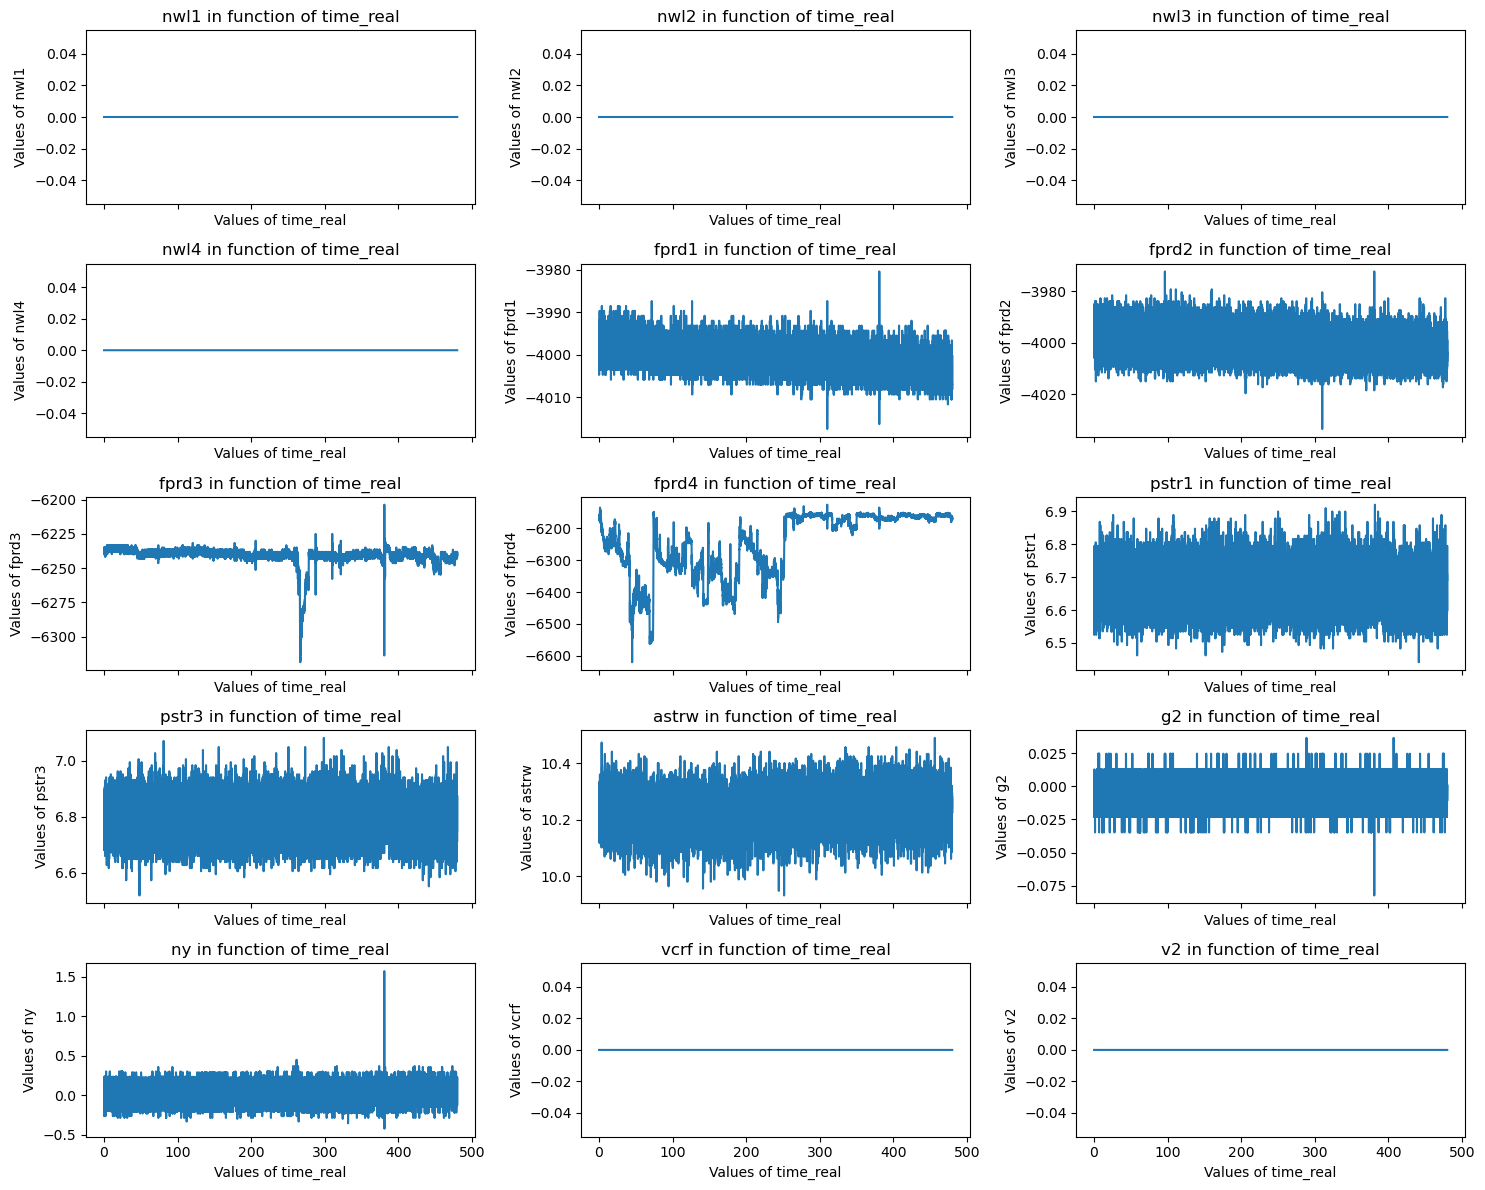

In [ ]:
# Visualize a session from the first dataset (used for training)
df = data_dict[list_session[0]].copy()
df = preprocessing.clean_dataframe(df)
cols = df.columns[1:-1]
visualisation_plot(df, cols)

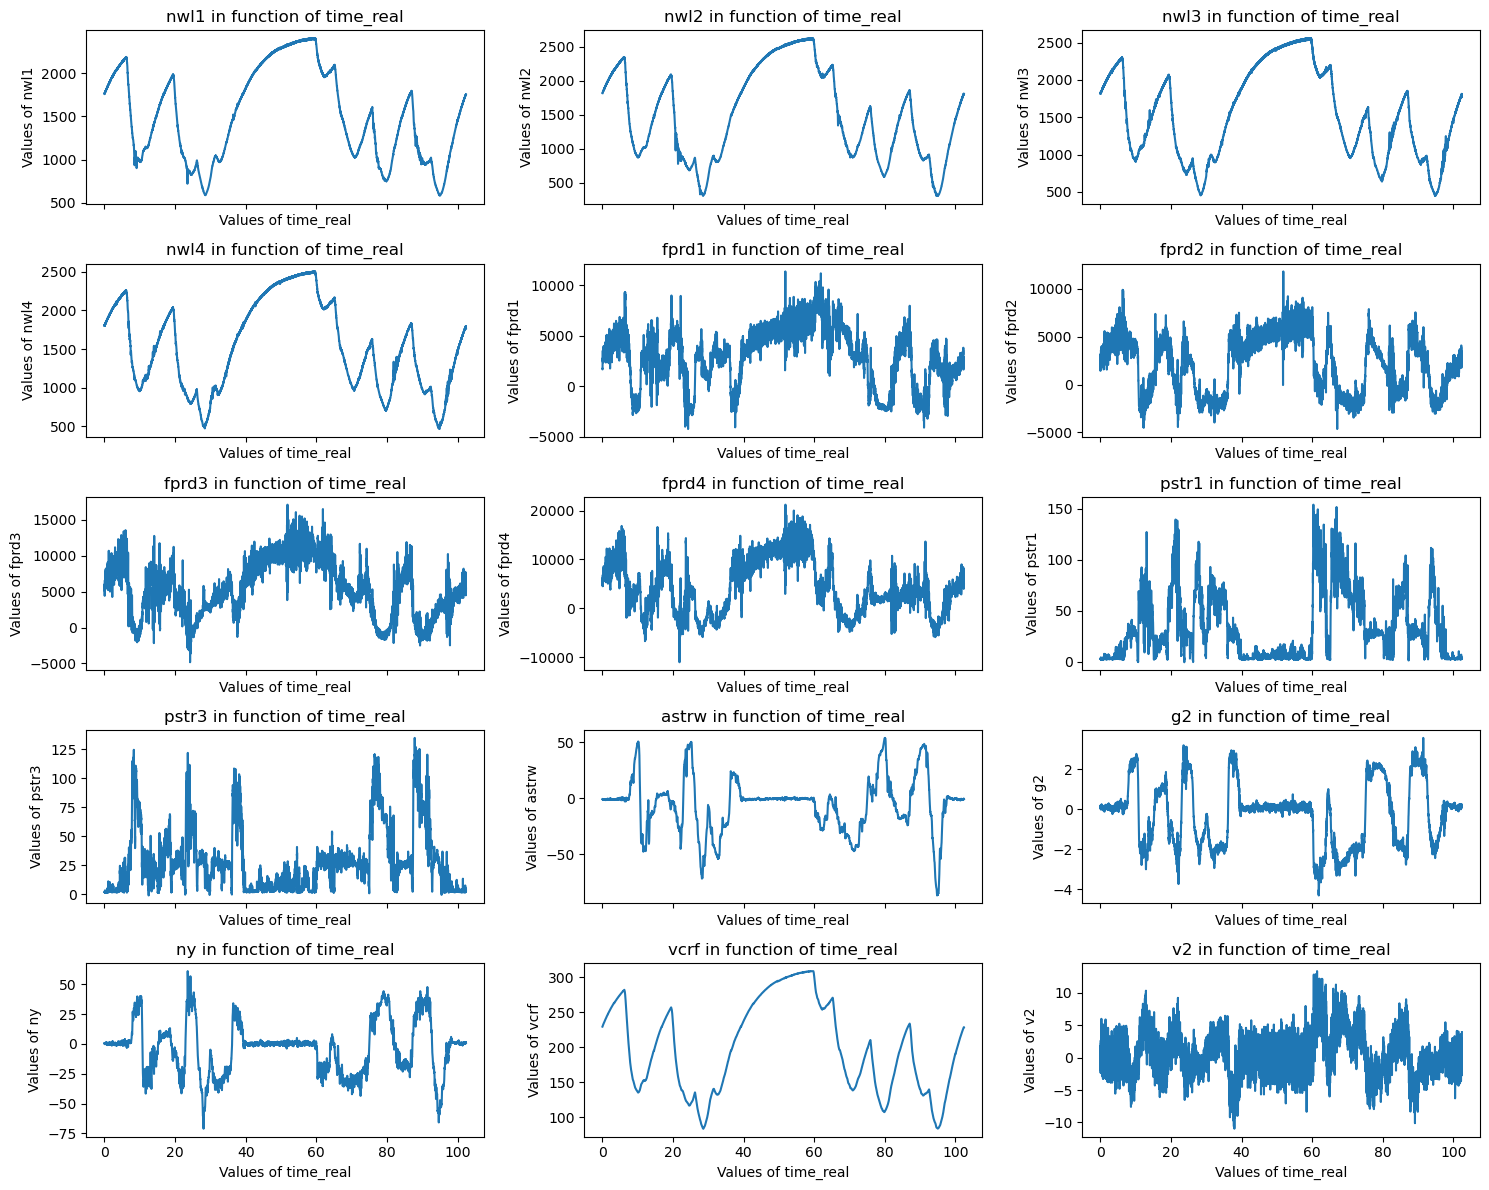

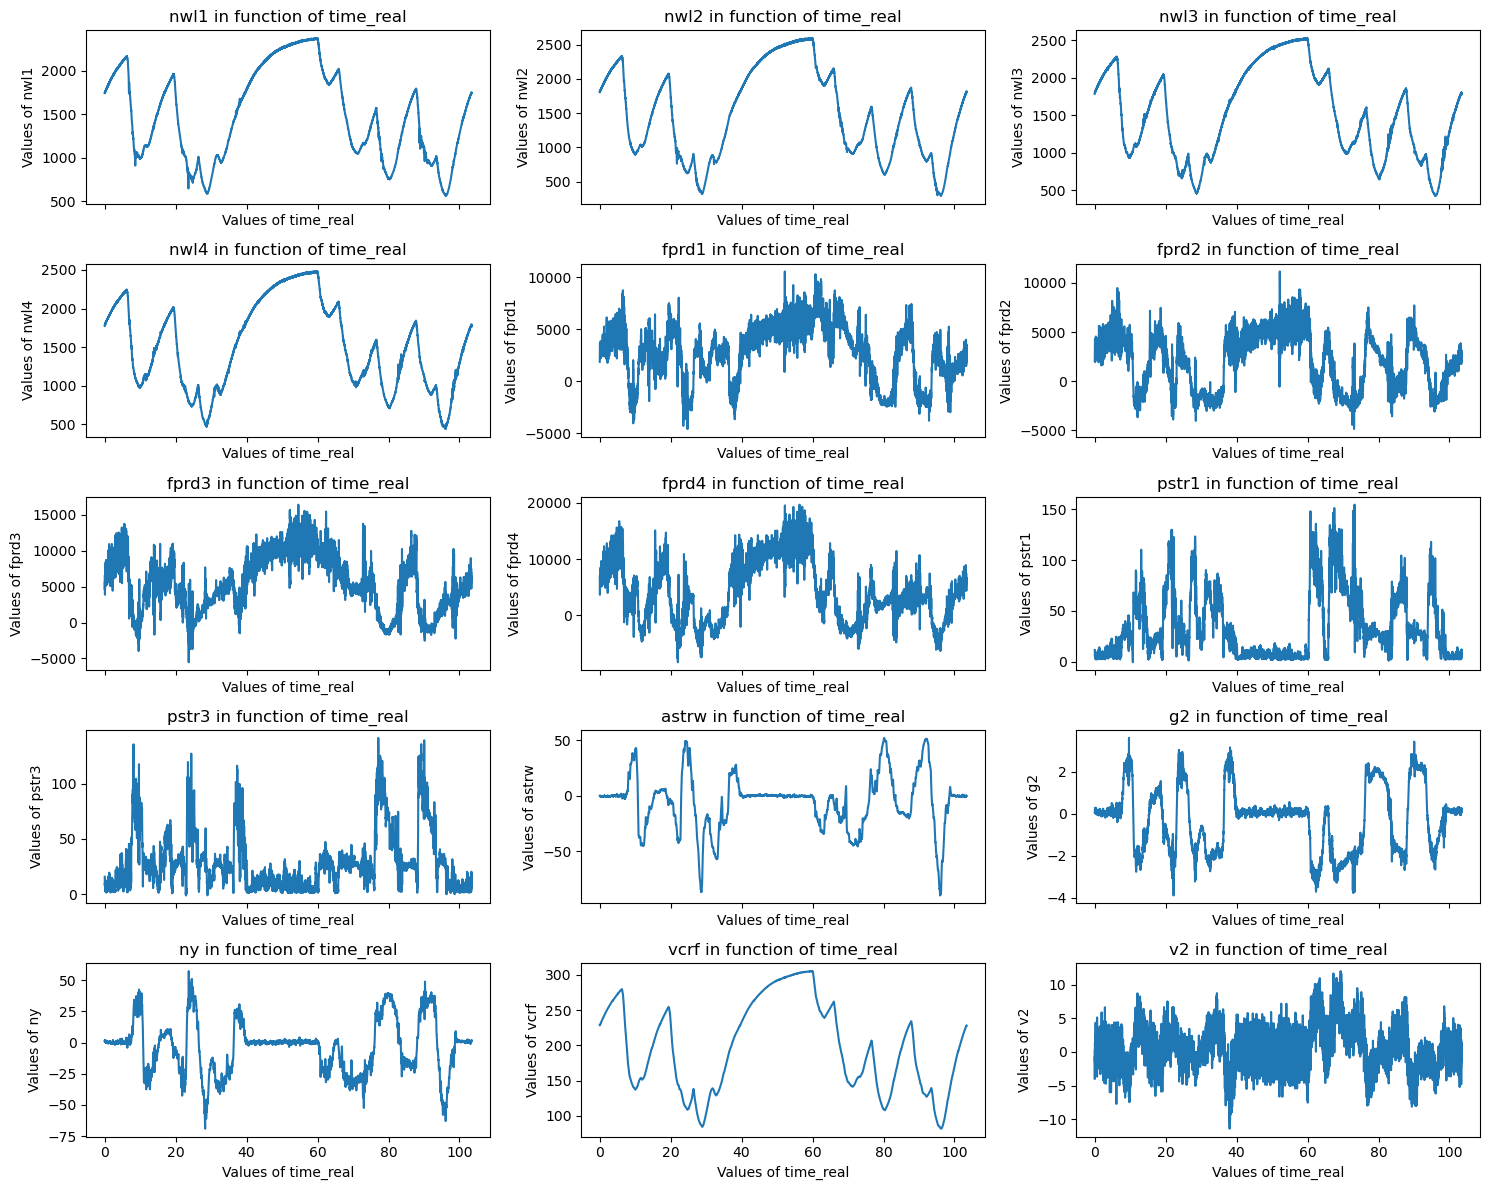

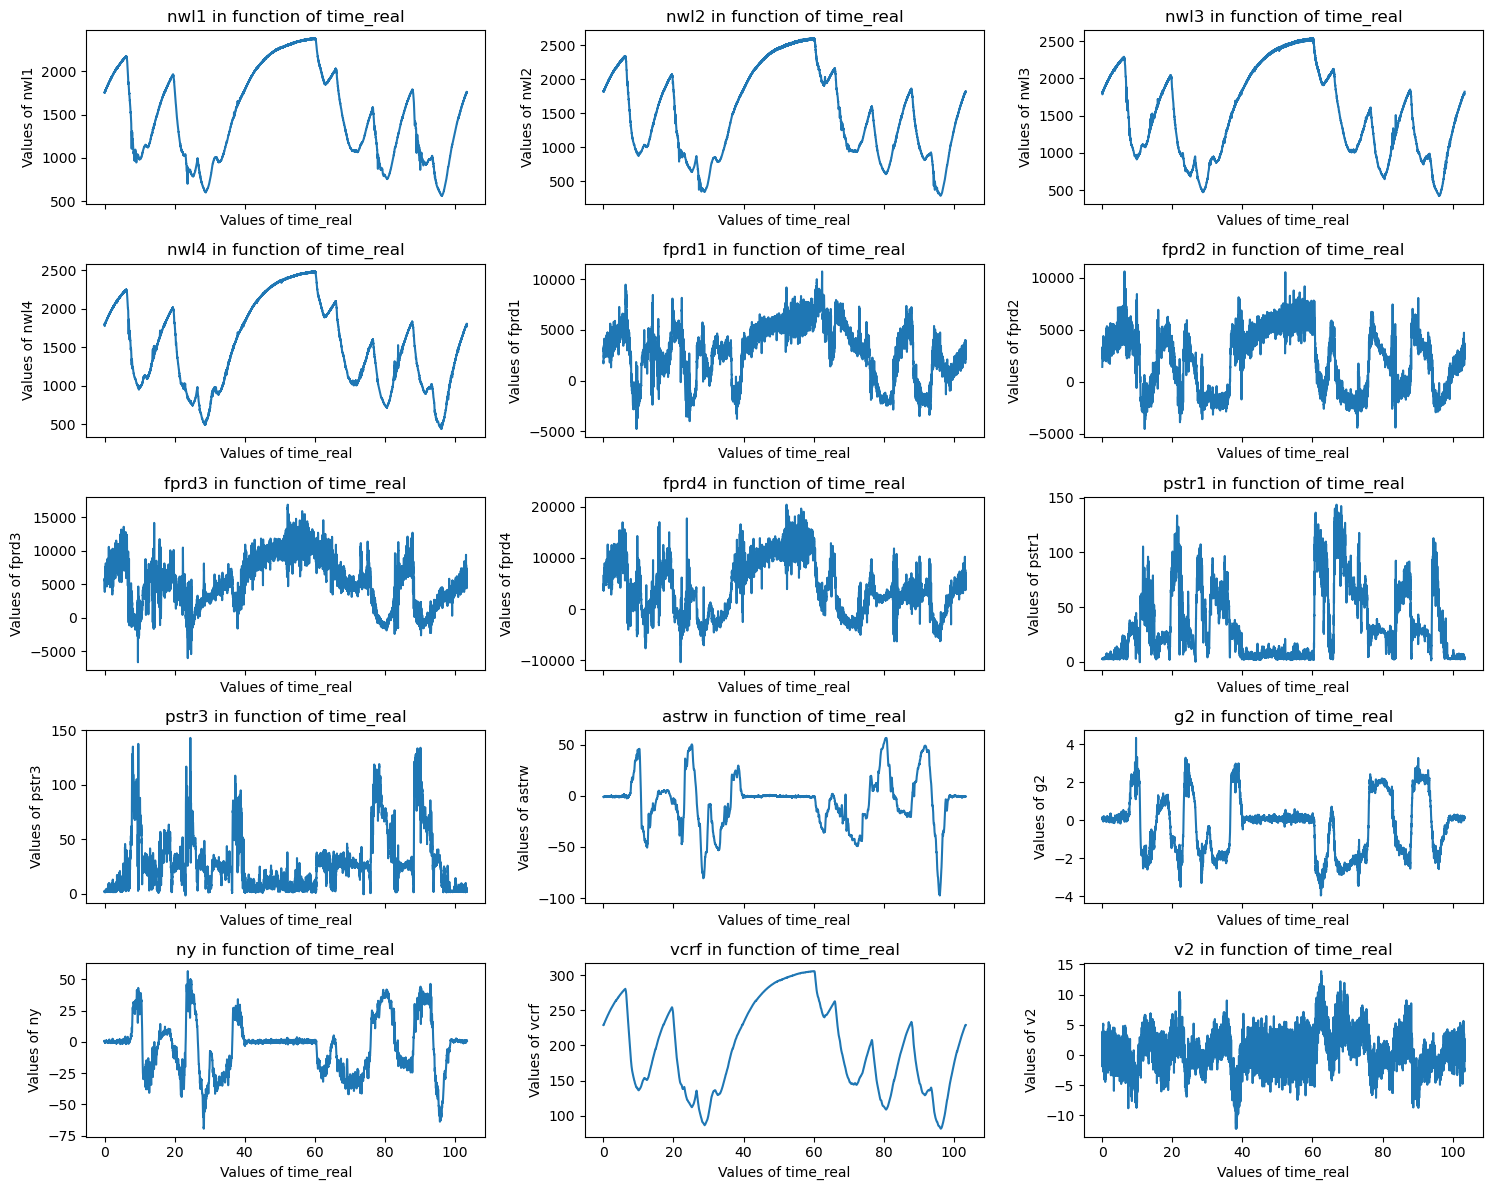

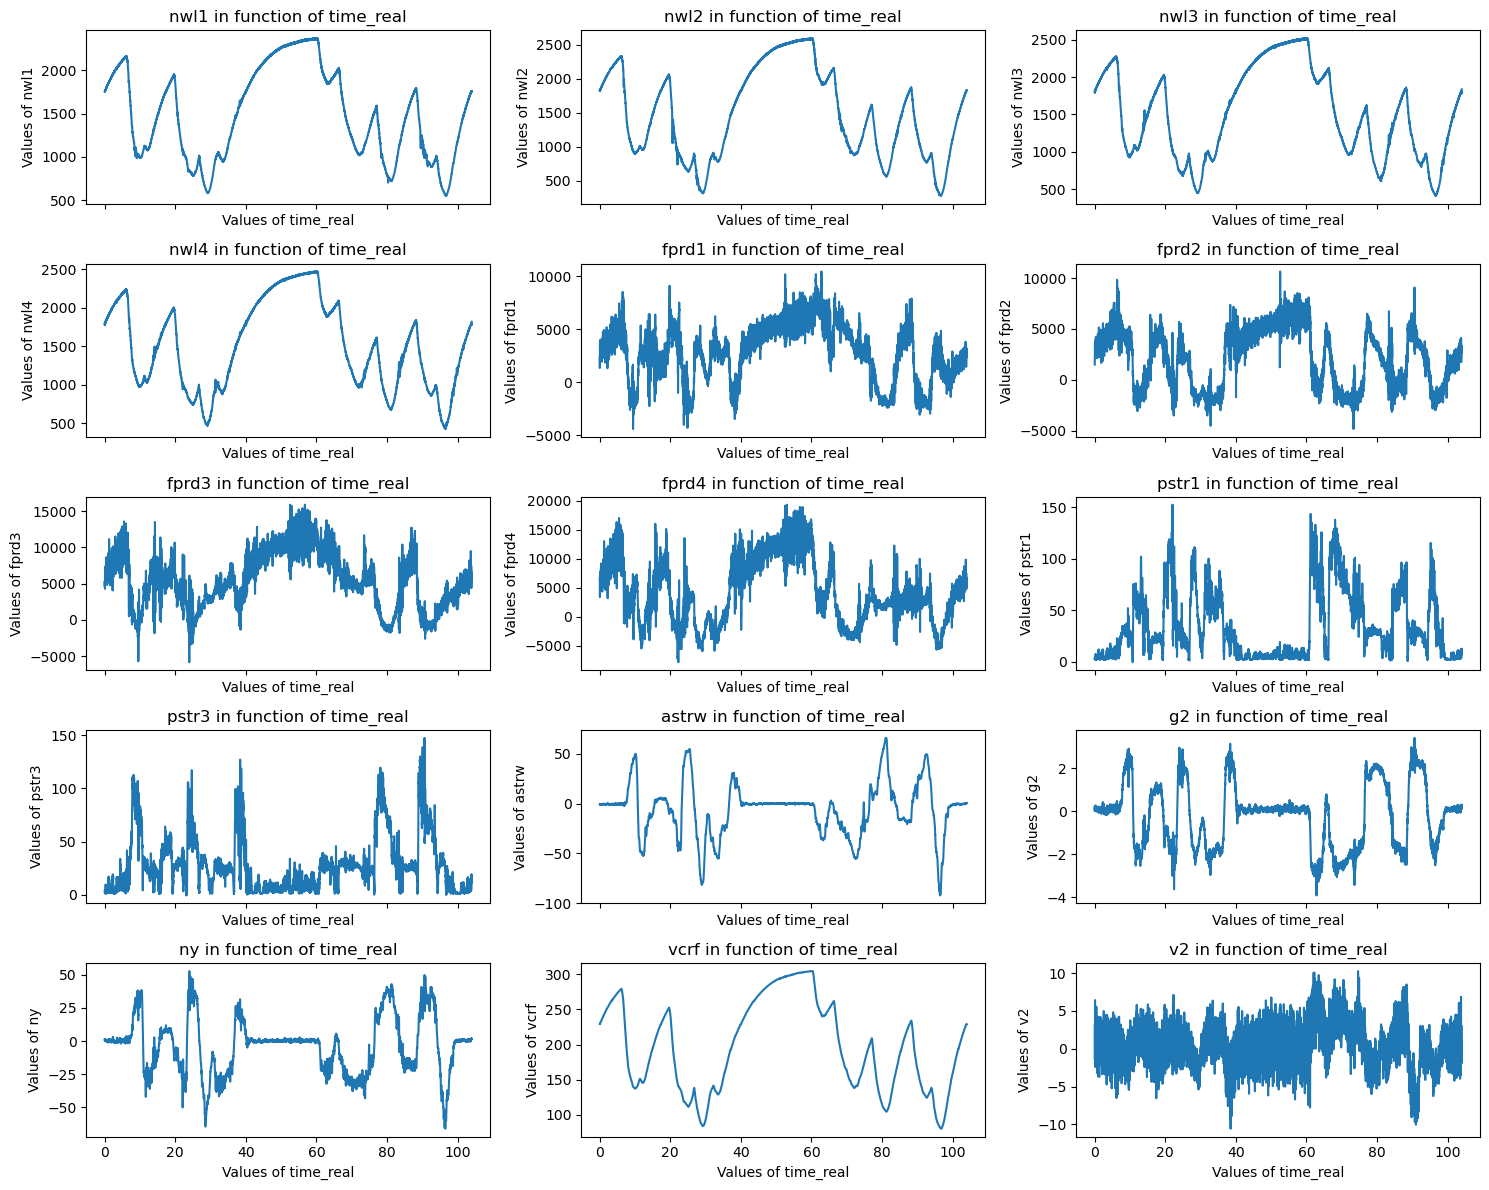

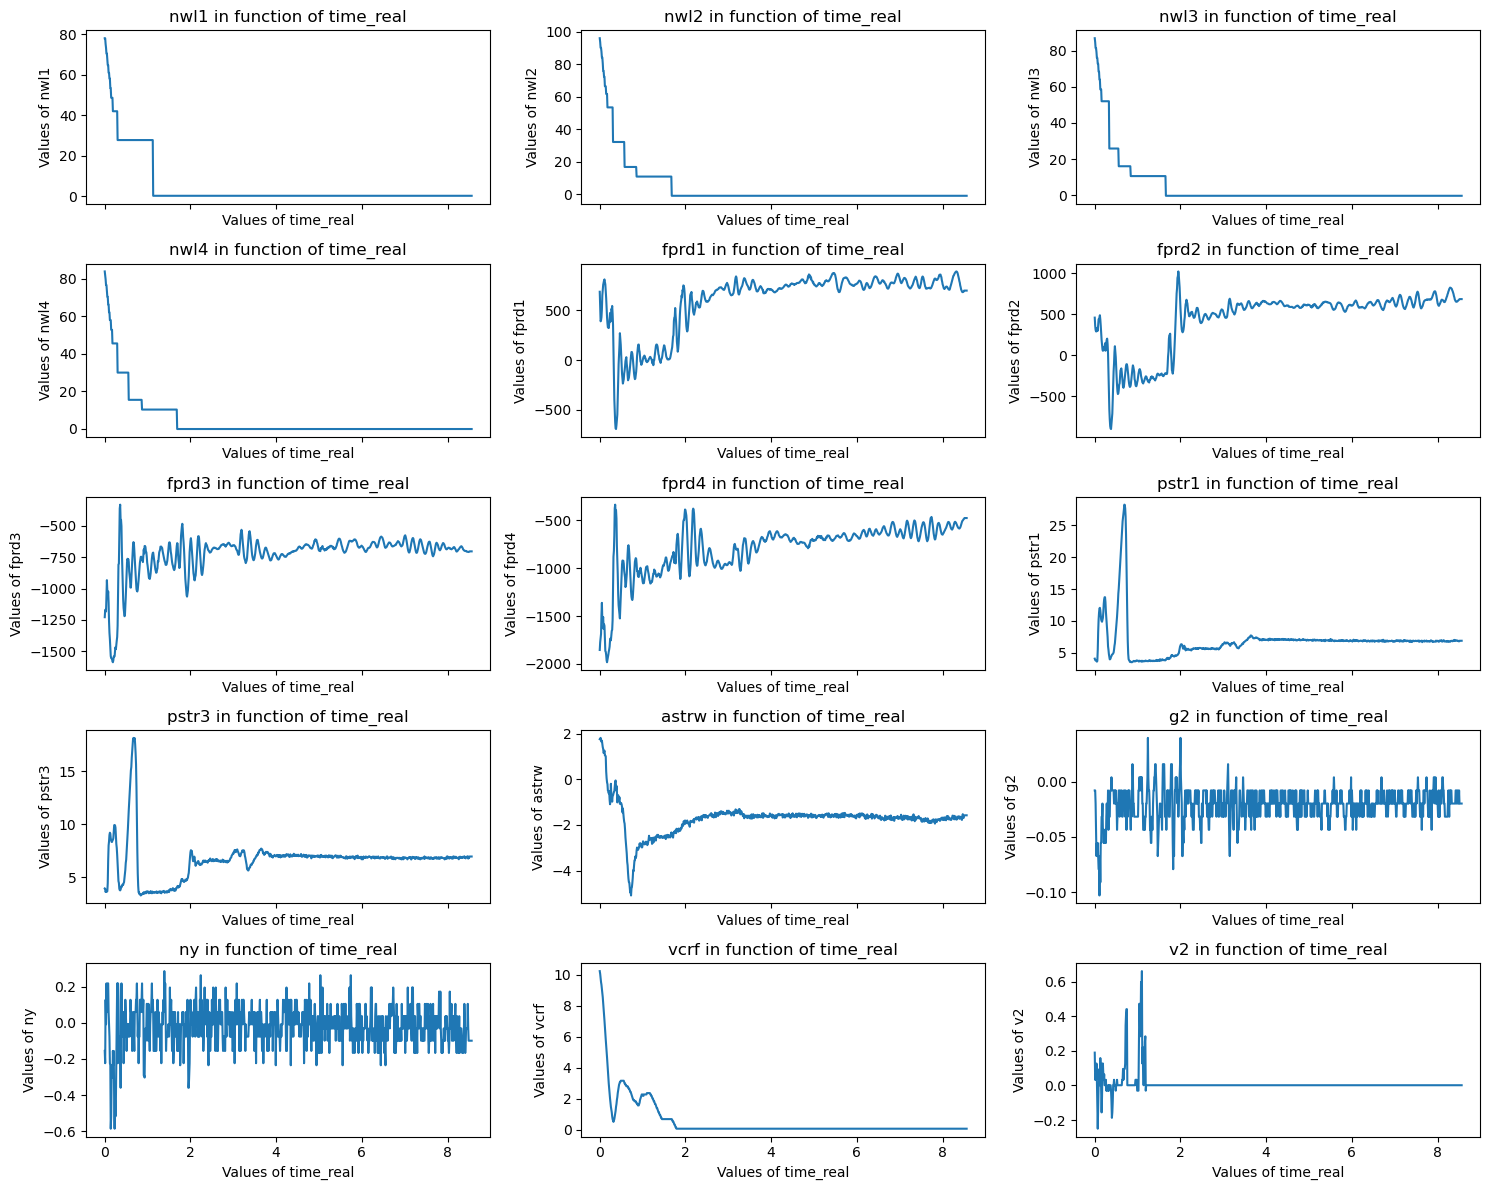

In [29]:
# Visualize a session from the second dataset (maybe used for testing)
for s in list_session2[:5]:
    df = data_dict2[s].copy()
    df = preprocessing.clean_dataframe(df)
    cols = df.columns[1:-1]
    visualisation_plot(df, cols)